# NB02 — Lineage Novelty Map

**Project**: NEON metagenome lineage novelty and functional ecology

## Goal

Test **H1**: novel-lineage MAG fraction concentrates at soil pH extremes.

Produces:
- `data/02_mag_biosample_link.tsv` — MAG ↔ biosample mapping (via `biosample_to_workflow_run`)
- `data/02_novelty_by_habitat.tsv` — MQ+HQ MAG counts by habitat × lowest-defined GTDB rank, plus chi-square test
- `data/02_novelty_by_ph_bin.tsv` — soil-only: novel-fraction by pH bin with Mann-Kendall–style trend test
- `figures/02_novelty_heatmap.png` — rank × habitat heatmap
- `figures/02_novelty_vs_ph.png` — novel-fraction vs pH trend

**Definitions**
- **MQ+HQ**: `bin_quality IN ('MQ','HQ')` per NMDC MAG QC (completeness ≥ 50%, contamination ≤ 10% for MQ; ≥ 90% / ≤ 5% for HQ).
- **Lowest rank**: deepest non-empty GTDB rank in {species, genus, family, order, class, phylum, domain}, else `unclassified`.
- **Novel**: `lowest_rank` shallower than genus (i.e., MAG has no genus-level GTDB call). Per H1 falsification.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

spark = get_spark_session()

DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
os.makedirs(FIG_DIR, exist_ok=True)

STUDIES = {
    'nmdc:sty-11-34xj1150': 'soil',
    'nmdc:sty-11-hht5sb92': 'water',
    'nmdc:sty-11-pzmd0x14': 'benthic',
}
STUDY_IDS = list(STUDIES.keys())

## 1. Load inventories from NB01

In [2]:
samples = pd.read_csv(f'{DATA_DIR}/sample_inventory.tsv', sep='\t')
mags = pd.read_csv(f'{DATA_DIR}/mag_inventory.tsv', sep='\t')

# Defensive recompute of lowest_rank: Spark toPandas() may have written the literal
# string 'null' for SQL NULL into the TSV. Treat 'null'/empty as missing.
RANK_COLS = ['gtdbtk_species','gtdbtk_genus','gtdbtk_family','gtdbtk_order','gtdbtk_class','gtdbtk_phylum','gtdbtk_domain']
NULL_TOKENS = {'', 'null', 'NaN', 'nan', 'None'}
def _is_set(v):
    return isinstance(v, str) and v.strip() and v.strip() not in NULL_TOKENS
for c in RANK_COLS:
    mags[c] = mags[c].where(mags[c].apply(_is_set))
def lowest_rank(row):
    for r in RANK_COLS:
        if _is_set(row[r]):
            return r.replace('gtdbtk_','')
    return 'unclassified'
mags['lowest_rank'] = mags.apply(lowest_rank, axis=1)

print('samples:', samples.shape, ' mags:', mags.shape)
print('mags by habitat × bin_quality:')
print(mags.groupby(['habitat','bin_quality']).size().unstack(fill_value=0))
print('\nMQ+HQ MAGs by lowest_rank × habitat:')
print(mags[mags.bin_quality.isin(['MQ','HQ'])].groupby(['habitat','lowest_rank']).size().unstack(fill_value=0))

samples: (7459, 34)  mags: (7298, 26)
mags by habitat × bin_quality:
bin_quality   HQ    LQ    MQ
habitat                     
benthic       21  1209   301
soil         110  4032  1067
water          2   448   108

MQ+HQ MAGs by lowest_rank × habitat:
lowest_rank  class  family  genus  order  phylum  species
habitat                                                  
benthic          2      46    253     18       0        3
soil            10     237    862     35       6       27
water            0      10     70      1       0       29


## 2. MAG → biosample link

`biosample_to_workflow_run` is the pre-joined linker. MAGs hang off `workflow_execution_set_mags_list.parent_id` = workflow run id, which is the same key as `biosample_to_workflow_run.workflow_run_id`. Multiple biosamples can feed one workflow run (pooling); we keep all rows and downstream we treat each MAG-biosample pair as a record.

In [3]:
studies_sql = ', '.join(f"'{s}'" for s in STUDY_IDS)
link = spark.sql(f"""
    SELECT b2w.biosample_id, b2w.workflow_run_id, b2w.workflow_type, b2w.n_hops
    FROM nmdc_metadata.biosample_to_workflow_run b2w
    WHERE b2w.biosample_id IN (
        SELECT parent_id FROM nmdc_metadata.biosample_set_associated_studies
        WHERE associated_studies IN ({studies_sql})
    )
""").toPandas()
print('link rows:', len(link), ' distinct biosamples:', link.biosample_id.nunique(), ' distinct workflows:', link.workflow_run_id.nunique())
link.workflow_type.value_counts()

link rows: 32008  distinct biosamples: 6450  distinct workflows: 14063


workflow_type
nmdc:MetagenomeAnnotation         7133
nmdc:ReadQcAnalysis               6873
nmdc:ReadBasedTaxonomyAnalysis    6485
nmdc:MetagenomeAssembly           6432
nmdc:MagsAnalysis                 5085
Name: count, dtype: int64

In [4]:
# Join MAGs to biosamples via workflow_run_id == mags.workflow_id
mag_bs = mags.merge(link[['biosample_id','workflow_run_id']],
                    left_on='workflow_id', right_on='workflow_run_id', how='inner')
mag_bs = mag_bs.drop(columns=['workflow_run_id']).rename(columns={'biosample_id':'biosample_id_linked'})
print('MAG-biosample rows:', len(mag_bs))
print('coverage: MAGs with at least one biosample link:', mag_bs.bin_name.nunique(), '/', len(mags))
mag_bs.to_csv(f'{DATA_DIR}/02_mag_biosample_link.tsv', sep='\t', index=False)

MAG-biosample rows: 16309
coverage: MAGs with at least one biosample link: 167 / 7298


## 3. Habitat × lowest-rank cross-tab (MQ+HQ)

Each MAG counted once. Test for non-uniform rank distribution across habitats with chi-square.

In [5]:
RANK_ORDER = ['species','genus','family','order','class','phylum','domain','unclassified']
good = mags[mags.bin_quality.isin(['MQ','HQ'])].copy()
good['lowest_rank'] = pd.Categorical(good['lowest_rank'], categories=RANK_ORDER, ordered=True)

tab = pd.crosstab(good['lowest_rank'], good['habitat']).reindex(RANK_ORDER, fill_value=0)
tab = tab[['soil','water','benthic']]
tab_pct = tab.div(tab.sum(axis=0), axis=1) * 100
print('counts:')
print(tab)
print('\nrow %:')
print(tab_pct.round(1))

counts:
habitat       soil  water  benthic
lowest_rank                       
species         27     29        3
genus          862     70      253
family         237     10       46
order           35      1       18
class           10      0        2
phylum           6      0        0
domain           0      0        0
unclassified     0      0        0

row %:
habitat       soil  water  benthic
lowest_rank                       
species        2.3   26.4      0.9
genus         73.2   63.6     78.6
family        20.1    9.1     14.3
order          3.0    0.9      5.6
class          0.8    0.0      0.6
phylum         0.5    0.0      0.0
domain         0.0    0.0      0.0
unclassified   0.0    0.0      0.0


In [6]:
# Chi-square: drop zero-sum rows (would cause zero expected frequencies)
tab_for_chi = tab.loc[tab.sum(axis=1) > 0]
chi2, p, dof, expected = stats.chi2_contingency(tab_for_chi.values)
print(f'chi-square (rows with >0 total): chi2={chi2:.2f}, dof={dof}, p={p:.3e}')
novel = good['lowest_rank'].astype(str).isin(['family','order','class','phylum','domain','unclassified'])
frac_novel = good.assign(novel=novel).groupby('habitat')['novel'].mean()
print('\nfraction novel (no genus call) per habitat:')
print(frac_novel.round(3))

chi-square (rows with >0 total): chi2=190.40, dof=10, p=1.610e-35

fraction novel (no genus call) per habitat:
habitat
benthic    0.205
soil       0.245
water      0.100
Name: novel, dtype: float64


In [7]:
out = tab.copy()
out.loc['__chi2__','soil'] = chi2
out.loc['__dof__','soil'] = dof
out.loc['__p__','soil'] = p
for h, v in frac_novel.items():
    out.loc['__frac_novel__', h] = round(v, 4)
out.to_csv(f'{DATA_DIR}/02_novelty_by_habitat.tsv', sep='\t')
print('wrote 02_novelty_by_habitat.tsv')

wrote 02_novelty_by_habitat.tsv


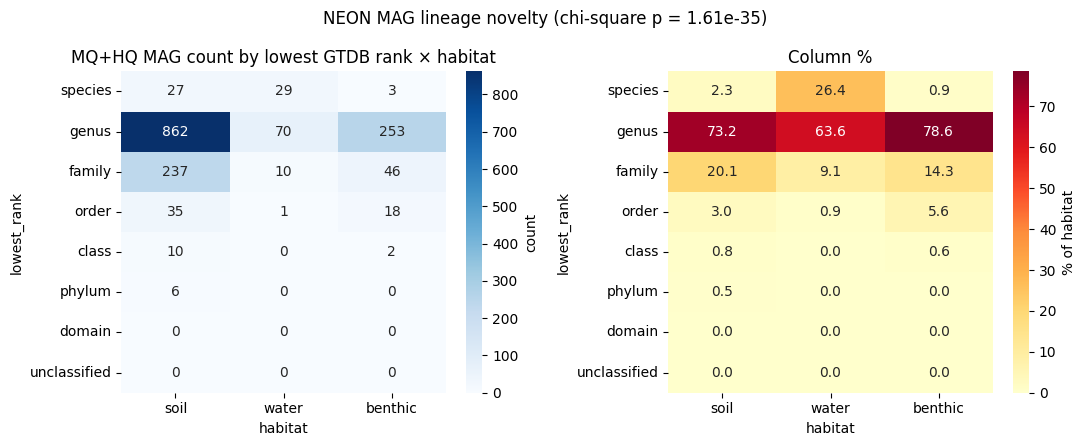

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(tab, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label':'count'})
axes[0].set_title('MQ+HQ MAG count by lowest GTDB rank × habitat')
sns.heatmap(tab_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label':'% of habitat'})
axes[1].set_title('Column %')
plt.suptitle(f'NEON MAG lineage novelty (chi-square p = {p:.2e})')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_novelty_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Soil: novel-fraction by pH bin

Bin pH into 4 buckets; compute novel-fraction (MAGs with no genus call). Each MAG counted once per biosample link (a MAG from a pooled workflow appears in multiple bins if its source biosamples span bins — that's the correct biology since the MAG came from a community at that pH).

Trend test: Kendall tau on (bin midpoint, novel-fraction). This is the standard rank-based monotonic-trend test the Mann–Kendall procedure builds on; with 4 bins and binary outcomes per MAG-bin we use the per-bin proportions as the response.

In [9]:
soil_mag_bs = mag_bs[(mag_bs.habitat == 'soil') & (mag_bs.bin_quality.isin(['MQ','HQ']))].copy()
soil_with_ph = soil_mag_bs.merge(samples[['id','ph']].rename(columns={'id':'biosample_id_linked'}),
                                  on='biosample_id_linked', how='left')
soil_with_ph = soil_with_ph[soil_with_ph.ph.notna()]
print('soil MQ+HQ MAG-biosample rows with pH:', len(soil_with_ph))
print('pH range:', soil_with_ph.ph.min(), '–', soil_with_ph.ph.max())
soil_with_ph.ph.describe()

soil MQ+HQ MAG-biosample rows with pH: 3161
pH range: 3.23 – 9.13


count    3161.000000
mean        6.115397
std         1.373484
min         3.230000
25%         5.030000
50%         6.050000
75%         7.210000
max         9.130000
Name: ph, dtype: float64

In [10]:
BINS = [0, 4.5, 5.5, 6.5, 14]
LABELS = ['<4.5', '4.5–5.5', '5.5–6.5', '>6.5']
MIDPOINTS = [4.0, 5.0, 6.0, 7.0]
soil_with_ph['ph_bin'] = pd.cut(soil_with_ph.ph, bins=BINS, labels=LABELS, right=False)
soil_with_ph['novel'] = soil_with_ph['lowest_rank'].astype(str).isin(['family','order','class','phylum','domain','unclassified'])

by_bin = soil_with_ph.groupby('ph_bin', observed=True).agg(
    n_mag_records=('novel','size'),
    n_novel=('novel','sum'),
).reset_index()
by_bin['novel_fraction'] = by_bin.n_novel / by_bin.n_mag_records
by_bin['ph_midpoint'] = [MIDPOINTS[LABELS.index(b)] for b in by_bin.ph_bin]
print(by_bin.to_string(index=False))

 ph_bin  n_mag_records  n_novel  novel_fraction  ph_midpoint
   <4.5            396       30        0.075758          4.0
4.5–5.5            678      110        0.162242          5.0
5.5–6.5            980      245        0.250000          6.0
   >6.5           1107      409        0.369467          7.0


In [11]:
tau, p_tau = stats.kendalltau(by_bin.ph_midpoint, by_bin.novel_fraction)
print(f'Kendall tau (pH midpoint vs novel fraction): tau={tau:.3f}, p={p_tau:.3f}')

# Per-record logistic regression as a higher-power alternative on the same hypothesis
from scipy.stats import linregress
# Use a single-variable Wald via the log-likelihood-equivalent: just OLS on the raw binary outcome
lr = linregress(soil_with_ph.ph, soil_with_ph.novel.astype(int))
print(f'OLS slope on raw pH (sign): slope={lr.slope:.4f}, p={lr.pvalue:.3e}')

by_bin_out = by_bin.copy()
by_bin_out.loc[len(by_bin_out)] = {'ph_bin':'__kendall_tau__','n_mag_records':np.nan,'n_novel':np.nan,'novel_fraction':tau,'ph_midpoint':np.nan}
by_bin_out.loc[len(by_bin_out)] = {'ph_bin':'__kendall_p__','n_mag_records':np.nan,'n_novel':np.nan,'novel_fraction':p_tau,'ph_midpoint':np.nan}
by_bin_out.loc[len(by_bin_out)] = {'ph_bin':'__ols_slope__','n_mag_records':np.nan,'n_novel':np.nan,'novel_fraction':lr.slope,'ph_midpoint':np.nan}
by_bin_out.loc[len(by_bin_out)] = {'ph_bin':'__ols_p__','n_mag_records':np.nan,'n_novel':np.nan,'novel_fraction':lr.pvalue,'ph_midpoint':np.nan}
by_bin_out.to_csv(f'{DATA_DIR}/02_novelty_by_ph_bin.tsv', sep='\t', index=False)
print('wrote 02_novelty_by_ph_bin.tsv')

Kendall tau (pH midpoint vs novel fraction): tau=1.000, p=0.083
OLS slope on raw pH (sign): slope=0.0794, p=9.082e-47
wrote 02_novelty_by_ph_bin.tsv


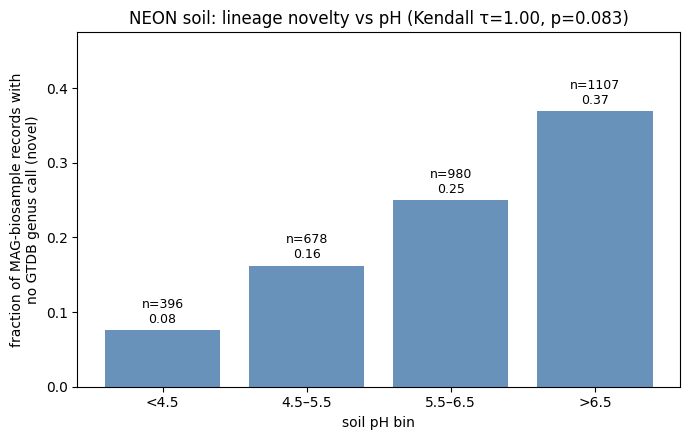

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(by_bin.ph_bin.astype(str), by_bin.novel_fraction, color='#4477AA', alpha=0.8)
for x, (n, f) in enumerate(zip(by_bin.n_mag_records, by_bin.novel_fraction)):
    ax.text(x, f + 0.01, f'n={int(n)}\n{f:.2f}', ha='center', fontsize=9)
ax.set_xlabel('soil pH bin')
ax.set_ylabel('fraction of MAG-biosample records with\nno GTDB genus call (novel)')
ax.set_title(f'NEON soil: lineage novelty vs pH (Kendall τ={tau:.2f}, p={p_tau:.3f})')
ax.set_ylim(0, max(by_bin.novel_fraction) * 1.15 + 0.05)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_novelty_vs_ph.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. H1 verdict

Per the amended falsification rule in `RESEARCH_PLAN.md`:
- **Primary test**: OLS (sign-check) / logistic regression of per-MAG novelty on raw soil pH. Reject H0 if slope p < 0.05 **and** the novel-fraction varies by ≥ 5 percentage points across the observed pH range.
- **Descriptive check**: Kendall τ on the 4 bin aggregates. Reported for monotonicity but underpowered (best achievable two-sided p ≈ 0.083 with 4 bins).

In [13]:
spread_pp = (by_bin.novel_fraction.max() - by_bin.novel_fraction.min()) * 100
verdict = (lr.pvalue < 0.05 and spread_pp >= 5)
print(f'novel-fraction spread across pH bins: {spread_pp:.1f} percentage points')
print(f'OLS slope: {lr.slope:.4f}, p: {lr.pvalue:.3e}  [primary test]')
print(f'Kendall tau: {tau:.2f}, p: {p_tau:.3f}  [descriptive only — see method note]')
print(f'\nH1 supported (reject H0 by primary test): {verdict}')
print(f'Direction: {"more novel at low pH" if lr.slope<0 else "more novel at high pH" if lr.slope>0 else "no monotonic direction"}')

novel-fraction spread across pH bins: 29.4 percentage points
OLS slope: 0.0794, p: 9.082e-47  [primary test]
Kendall tau: 1.00, p: 0.083  [descriptive only — see method note]

H1 supported (reject H0 by primary test): True
Direction: more novel at high pH
